Libraries

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from PIL import ImageOps

Edge Detection


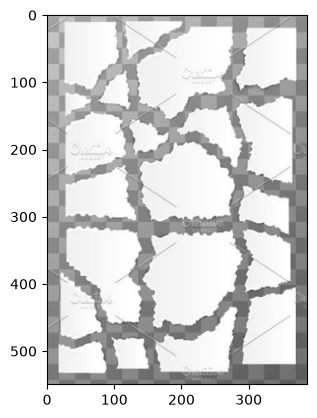

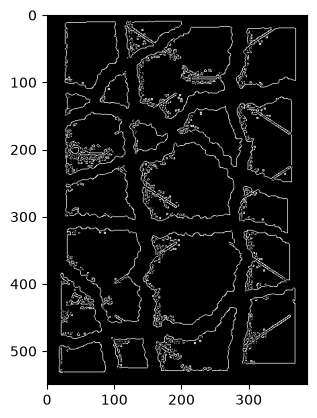

In [15]:
image_path = r'D:\PythonProject1\Intern\Images\img111.png'
image = cv2.imread(image_path)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)
_, thresh = cv2.threshold(gray_image, 240, 245, cv2.THRESH_BINARY_INV)
canny = cv2.Canny(thresh,50,150)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(canny, cmap='gray')
plt.show()

Seperate Each Torn Fragment using Contours

In [16]:
_, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
contour_img = image.copy()
cv2.drawContours(contour_img, valid_contours, -1, (0, 255, 0), 3)


array([[[199, 199, 199],
        [199, 199, 199],
        [199, 199, 199],
        ...,
        [169, 169, 169],
        [166, 166, 166],
        [166, 166, 166]],

       [[205, 205, 205],
        [205, 205, 205],
        [204, 204, 204],
        ...,
        [167, 167, 167],
        [167, 167, 167],
        [168, 168, 168]],

       [[182, 182, 182],
        [181, 181, 181],
        [180, 180, 180],
        ...,
        [151, 151, 151],
        [148, 148, 148],
        [149, 149, 149]],

       ...,

       [[147, 147, 147],
        [147, 147, 147],
        [147, 147, 147],
        ...,
        [111, 111, 111],
        [110, 110, 110],
        [110, 110, 110]],

       [[146, 146, 146],
        [146, 146, 146],
        [146, 146, 146],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]],

       [[146, 146, 146],
        [146, 146, 146],
        [146, 146, 146],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]]

In [17]:
isolated_pieces_list = []  
count=0
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad =0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    rgb_piece = cv2.cvtColor(isolated_piece, cv2.COLOR_BGR2RGB)
    isolated_pieces_list.append(rgb_piece)
    count += 1
    # plt.imshow(rgb_piece)
    # plt.show()

Add padding on Border

In [18]:
cc=0
for i in isolated_pieces_list:
    if count==cc:
        break
    else:
        top,bottom,left,right=10,10,10,10
        padding_color = [0,0,0]
        vertical = cv2.copyMakeBorder(i,0, 0,left,right,borderType=cv2.BORDER_CONSTANT,value=padding_color)
        horizontal=cv2.copyMakeBorder(i,top,bottom,0,0,borderType=cv2.BORDER_CONSTANT,value=padding_color)
        image =vertical


        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
        _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)

        points = cv2.findNonZero(thresh)
        x, y, w, h = cv2.boundingRect(points)
        img_height = thresh.shape[0]
        tol = 3
        top = []
        bottom = []

        for col in range(x, x + w):
            white_pixels = np.where(thresh[:, col] == 255)[0]
            if len(white_pixels) > 0:
                actual_top_edge = white_pixels[0]
                top.append(actual_top_edge - y)
                
                actual_bottom_edge = white_pixels[-1]
                absolute_bottom_peak = y + h
                bottom.append(absolute_bottom_peak - actual_bottom_edge)
        avg1_top_deviation = np.mean(top) if top else 0
        avg1_bottom_deviation = np.mean(absolute_bottom_peak) if bottom else 0

        top1_is_torn = avg1_top_deviation > tol or avg1_top_deviation<0
        bottom1_is_torn = avg1_bottom_deviation > tol or avg1_bottom_deviation<0

        image=horizontal
        for col in range(y, y + h):
            white_pixels = np.where(thresh[col:,] == 255)[0]
            if len(white_pixels) > 0:
                actual_top_edge = white_pixels[0]
                top.append(actual_top_edge - x)
                
                actual_bottom_edge = white_pixels[-1]
                absolute_bottom_peak = x + w
                bottom.append(absolute_bottom_peak - actual_bottom_edge)

        avg_top_deviation = np.mean(top) if top else 0
        avg_bottom_deviation = np.mean(bottom) if bottom else 0

        top_is_torn = avg_top_deviation > tol or avg_top_deviation <0
        bottom_is_torn = avg_bottom_deviation > tol or avg_bottom_deviation<0


        # print(f"left Side:   {'TORN' if top_is_torn else 'STRAIGHT '} (Avg : {avg_top_deviation:.2f}px)")
        # print(f"right Side:  {'TORN' if bottom_is_torn else 'STRAIGHT'} (Avg {avg_bottom_deviation:.2f}px)")
        # print(f"Top Side:    {'TORN' if top1_is_torn else 'STRAIGHT'} (Avg {avg1_top_deviation:.2f}px)")
        # print(f"Bottom Side: {'TORN' if bottom1_is_torn else 'STRAIGHT'} (Avg  {avg1_bottom_deviation:.2f}px)")
        
        cc+=1
        
        # plt.imshow(vertical)

        # plt.show()
        # plt.imshow(horizontal)

        # plt.show()

                


Finding Peak

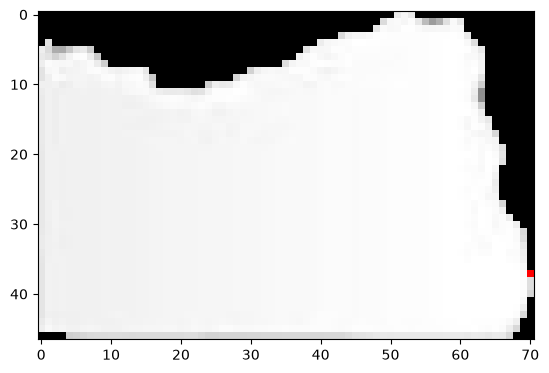

37
70


In [19]:
img = isolated_pieces_list[0]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
y, x = np.where(thresh == 255)
highest = np.argmax(x)
peak_x = x[highest]
peak_y = y[highest]
output_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img.copy()
cv2.circle(output_img, (peak_x, peak_y), 0, (0,0,255), -1)
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.show()
print(peak_y)
print(peak_x)

Add padding using peak

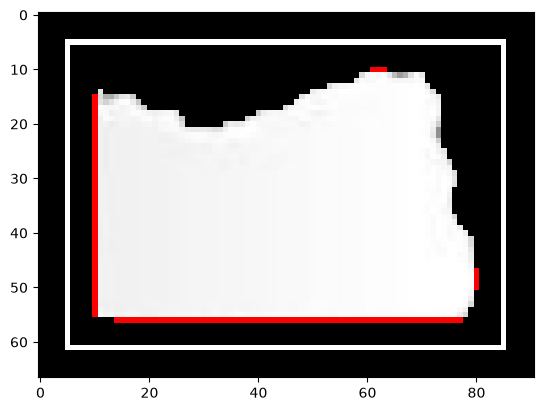

In [26]:
bottom = np.max(y)  
right = np.max(x)  
top= np.min(y) 
left = np.min(x)  
output= cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img.copy()
output = cv2.copyMakeBorder(output,10,10,10,10,borderType=cv2.BORDER_CONSTANT,value=padding_color)

bottom += 10
right += 10
top += 10
left += 10
y1 = x[y == (bottom-10)]+10
for peak_y in y1:
    cv2.circle(output, (peak_y, bottom), 0, (0, 0, 255), -1)
    #print(peak_y, x1)

y2 = y[x == right-10]+10 
for peak_y in y2:
    cv2.circle(output, (right, peak_y), 0, (0, 0, 255), -1) 
    #print(x2,peak_y)

y3 = x[y == top-10]+10 
for peak_y in y3:
    cv2.circle(output, (peak_y, top), 0, (0, 0, 255), -1)
    #print(peak_y, x3)
y4 = y[x == left-10]+10 
for peak_y in y4:
    cv2.circle(output, (left, peak_y), 0, (0, 0, 255), -1)

g1= 5
b1=(left - g1, top - g1)
b2=(right + g1, bottom + g1)
cv2.rectangle(output, b1, b2, (255, 255, 255), 1)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.show()

